In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim



/home/norah/.pyenv/versions/ai/lib/python3.12/site-packages/skimage/metrics/simple_metrics.py:2: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import entropy


In [2]:
# -------------------------
# Dataset setup
# -------------------------
DATASET = "dataset"

image_names = [
    "camera",
    "coins",
    "text",
    "rice",
    "astronaut"
]



In [3]:
# -------------------------
# Load image
# -------------------------
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")

    # Convert OpenCV BGR to RGB for color images
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img




In [4]:
# -------------------------
# Evaluation metrics
# -------------------------
def evaluate(clean, denoised):
    psnr_value = psnr(clean, denoised, data_range=255)

    if len(clean.shape) == 3:
        ssim_value = ssim(clean, denoised, channel_axis=-1, data_range=255)
    else:
        ssim_value = ssim(clean, denoised, data_range=255)

    return psnr_value, ssim_value




In [6]:
# -------------------------
# Method 1: Spatial-domain denoising
# Students may modify this method
# -------------------------
def spatial_denoising(img, method="median", kernel_size=5):
    """
    Spatial-domain denoising method.

    Students should choose and tune one spatial-domain method.

    Examples:
    - median filter
    - Gaussian filter
    - mean filter
    - bilateral filter
    """

    if method == "median":
        return cv2.medianBlur(img, kernel_size)

    elif method == "gaussian":
        return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

    elif method == "mean":
        return cv2.blur(img, (kernel_size, kernel_size))

    elif method == "bilateral":
        return cv2.bilateralFilter(img, d=kernel_size, sigmaColor=75, sigmaSpace=75)

    else:
        raise ValueError("Unknown spatial method selected.")




In [7]:
# -------------------------
# Method 2: Frequency-domain Gaussian low-pass filter
# -------------------------
def gaussian_lowpass_filter(shape, cutoff):
    """
    Create a Gaussian low-pass filter.

    shape: image shape, for grayscale image only
    cutoff: controls amount of smoothing
    """

    rows, cols = shape
    crow, ccol = rows // 2, cols // 2

    u = np.arange(rows)
    v = np.arange(cols)

    V, U = np.meshgrid(v, u)

    distance_squared = (U - crow)**2 + (V - ccol)**2

    H = np.exp(-distance_squared / (2 * cutoff**2))

    return H


def frequency_gaussian_denoising_gray(img_gray, cutoff=40):
    """
    Apply Gaussian low-pass filtering in frequency domain
    to a single grayscale channel.
    """

    img_float = img_gray.astype(np.float32)

    # Fourier transform
    F = np.fft.fft2(img_float)

    # Shift zero frequency to center
    F_shifted = np.fft.fftshift(F)

    # Create Gaussian low-pass filter
    H = gaussian_lowpass_filter(img_gray.shape, cutoff)

    # Apply filter in frequency domain
    G_shifted = F_shifted * H

    # Shift back
    G = np.fft.ifftshift(G_shifted)

    # Inverse Fourier transform
    img_filtered = np.fft.ifft2(G)

    # Keep real part and clip values
    img_filtered = np.real(img_filtered)
    img_filtered = np.clip(img_filtered, 0, 255)

    return img_filtered.astype(np.uint8)


def frequency_gaussian_denoising(img, cutoff=40):
    """
    Apply Gaussian low-pass filtering in the frequency domain.

    Works for both grayscale and RGB images.
    For RGB images, the filter is applied to each channel separately.
    """

    if len(img.shape) == 2:
        return frequency_gaussian_denoising_gray(img, cutoff)

    channels = []
    for c in range(img.shape[2]):
        filtered_channel = frequency_gaussian_denoising_gray(img[:, :, c], cutoff)
        channels.append(filtered_channel)

    return np.stack(channels, axis=2)




In [8]:
# -------------------------
# Parameter settings to test
# Students should experiment with these
# -------------------------
spatial_kernel_sizes = [3, 9, 13]
frequency_cutoffs = [20, 50, 90]





Processing image: camera
Spatial median, kernel=3: PSNR=25.71, SSIM=0.4939
Spatial median, kernel=9: PSNR=24.41, SSIM=0.6469
Spatial median, kernel=13: PSNR=23.05, SSIM=0.6337
Frequency Gaussian, cutoff=20: PSNR=22.57, SSIM=0.6268
Frequency Gaussian, cutoff=50: PSNR=25.84, SSIM=0.6900
Frequency Gaussian, cutoff=90: PSNR=26.98, SSIM=0.6165


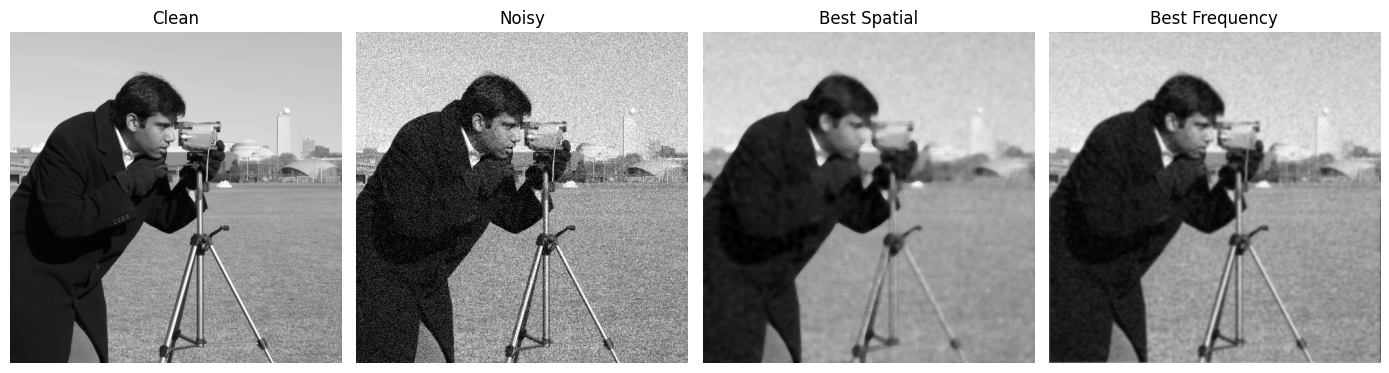


Processing image: coins
Spatial median, kernel=3: PSNR=28.07, SSIM=0.8536
Spatial median, kernel=9: PSNR=24.30, SSIM=0.6936
Spatial median, kernel=13: PSNR=22.93, SSIM=0.6476
Frequency Gaussian, cutoff=20: PSNR=21.61, SSIM=0.5585
Frequency Gaussian, cutoff=50: PSNR=23.56, SSIM=0.5521
Frequency Gaussian, cutoff=90: PSNR=21.93, SSIM=0.4617


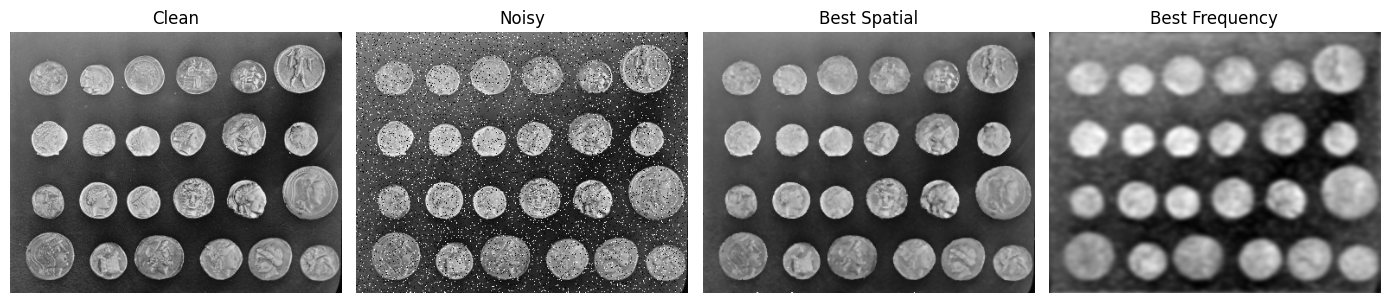


Processing image: text
Spatial median, kernel=3: PSNR=32.01, SSIM=0.9043
Spatial median, kernel=9: PSNR=23.76, SSIM=0.6270
Spatial median, kernel=13: PSNR=22.57, SSIM=0.5530
Frequency Gaussian, cutoff=20: PSNR=25.59, SSIM=0.6524
Frequency Gaussian, cutoff=50: PSNR=24.20, SSIM=0.4786
Frequency Gaussian, cutoff=90: PSNR=20.55, SSIM=0.3243


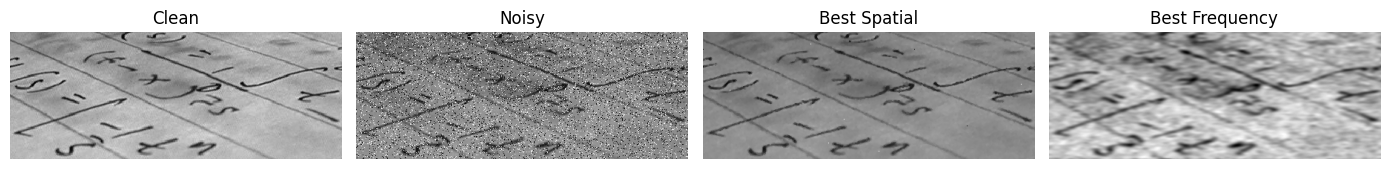


Processing image: rice
Spatial median, kernel=3: PSNR=23.03, SSIM=0.4602
Spatial median, kernel=9: PSNR=22.75, SSIM=0.5644
Spatial median, kernel=13: PSNR=21.67, SSIM=0.5380
Frequency Gaussian, cutoff=20: PSNR=22.02, SSIM=0.5731
Frequency Gaussian, cutoff=50: PSNR=24.48, SSIM=0.5947
Frequency Gaussian, cutoff=90: PSNR=23.22, SSIM=0.4792


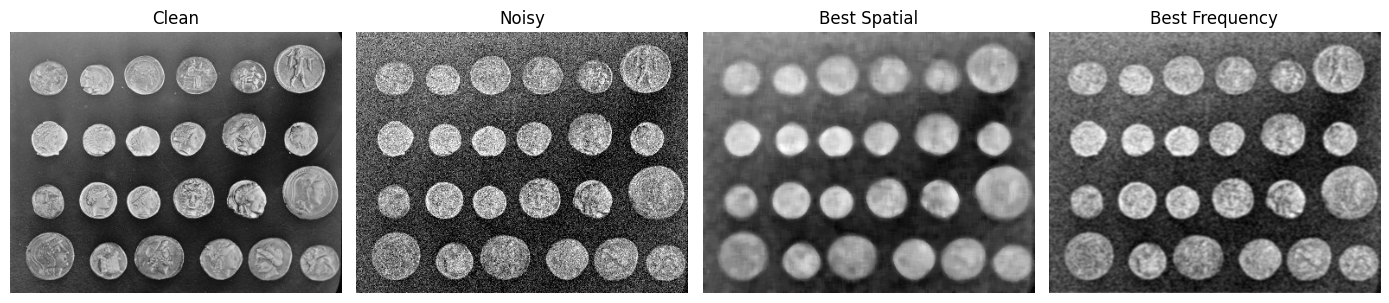


Processing image: astronaut
Spatial median, kernel=3: PSNR=30.32, SSIM=0.9375
Spatial median, kernel=9: PSNR=24.36, SSIM=0.8019
Spatial median, kernel=13: PSNR=22.36, SSIM=0.7277
Frequency Gaussian, cutoff=20: PSNR=19.82, SSIM=0.5283
Frequency Gaussian, cutoff=50: PSNR=22.87, SSIM=0.5929
Frequency Gaussian, cutoff=90: PSNR=22.51, SSIM=0.4893


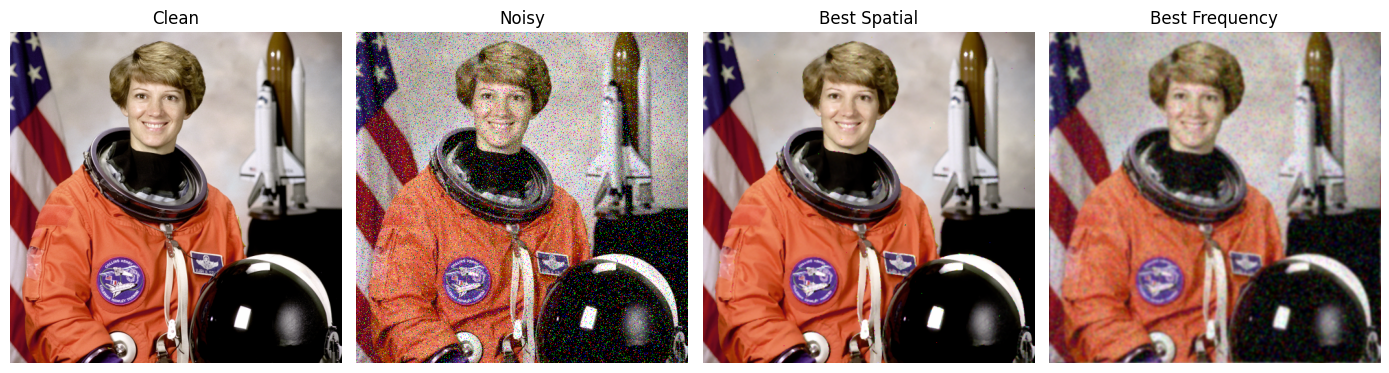

In [9]:
# -------------------------
# Main experiment
# -------------------------
results = []

for name in image_names:

    clean_path = os.path.join(DATASET, "clean", f"{name}.png")
    noisy_path = os.path.join(DATASET, "noisy", f"{name}_noisy.png")

    clean = load_image(clean_path)
    noisy = load_image(noisy_path)

    print(f"\nProcessing image: {name}")

    # -------------------------
    # Spatial-domain experiments
    # -------------------------
    best_spatial = None
    best_spatial_score = -1
    best_spatial_params = None
    
#    if name in ["coins", "text", "astronaut"]:
 #       chosen_method = "median"    
  #      
   # elif name == "rice":
    #    chosen_method = "bilateral"  # Best for speckle  

    #else:
     #   chosen_method = "gaussian"
     
    for k in spatial_kernel_sizes:
        denoised_spatial = spatial_denoising(
            noisy,
            method="median", #Choose the method you want to implement
            kernel_size = k
        )

        p, s = evaluate(clean, denoised_spatial)

        print(f"Spatial median, kernel={k}: PSNR={p:.2f}, SSIM={s:.4f}")

        # Here we select best result based on SSIM
        if s > best_spatial_score:
            best_spatial_score = s
            best_spatial = denoised_spatial
            best_spatial_params = k
            best_spatial_metrics = (p, s)

    # -------------------------
    # Frequency-domain experiments
    # -------------------------
    best_frequency = None
    best_frequency_score = -1
    best_frequency_params = None
    
    for cutoff in frequency_cutoffs:
        denoised_frequency = frequency_gaussian_denoising(
            noisy,
            cutoff=cutoff
        )

        p, s = evaluate(clean, denoised_frequency)

        print(f"Frequency Gaussian, cutoff={cutoff}: PSNR={p:.2f}, SSIM={s:.4f}")

        # Here we select best result based on SSIM
        if s > best_frequency_score:
            best_frequency_score = s
            best_frequency = denoised_frequency
            best_frequency_params = cutoff
            best_frequency_metrics = (p, s)

    # Store best results
    results.append([
        name,
        "Spatial",
        f"median, kernel={best_spatial_params}",
        best_spatial_metrics[0],
        best_spatial_metrics[1]
    ])

    results.append([
        name,
        "Frequency",
        f"Gaussian LPF, cutoff={best_frequency_params}",
        best_frequency_metrics[0],
        best_frequency_metrics[1]
    ])

 # -------------------------
    # Display results
    # -------------------------
    cmap = "gray" if len(clean.shape) == 2 else None

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(clean, cmap=cmap)
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(noisy, cmap=cmap)
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(best_spatial, cmap=cmap)
    plt.title("Best Spatial")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(best_frequency, cmap=cmap)
    plt.title("Best Frequency")
    plt.axis("off")

    plt.tight_layout()
    plt.show()




In [10]:
# -------------------------
# Final results table
# -------------------------
print("\nFinal Results")
print("-" * 90)
print(f"{'Image':12s} {'Method':12s} {'Parameters':28s} {'PSNR':>10s} {'SSIM':>10s}")
print("-" * 90)

for row in results:
    print(
        f"{row[0]:12s} "
        f"{row[1]:12s} "
        f"{row[2]:28s} "
        f"{row[3]:10.2f} "
        f"{row[4]:10.4f}"
    )





Final Results
------------------------------------------------------------------------------------------
Image        Method       Parameters                         PSNR       SSIM
------------------------------------------------------------------------------------------
camera       Spatial      median, kernel=9                  24.41     0.6469
camera       Frequency    Gaussian LPF, cutoff=50           25.84     0.6900
coins        Spatial      median, kernel=3                  28.07     0.8536
coins        Frequency    Gaussian LPF, cutoff=20           21.61     0.5585
text         Spatial      median, kernel=3                  32.01     0.9043
text         Frequency    Gaussian LPF, cutoff=20           25.59     0.6524
rice         Spatial      median, kernel=9                  22.75     0.5644
rice         Frequency    Gaussian LPF, cutoff=50           24.48     0.5947
astronaut    Spatial      median, kernel=3                  30.32     0.9375
astronaut    Frequency    Gaussia

In [12]:
# -------------------------
# Average results
# -------------------------
spatial_psnr = [r[3] for r in results if r[1] == "Spatial"]
spatial_ssim = [r[4] for r in results if r[1] == "Spatial"]

frequency_psnr = [r[3] for r in results if r[1] == "Frequency"]
frequency_ssim = [r[4] for r in results if r[1] == "Frequency"]

print("\nAverage Results")
print("-" * 50)
print(f"Spatial Method   : PSNR = {np.mean(spatial_psnr):.2f}, SSIM = {np.mean(spatial_ssim):.4f}")
print(f"Frequency Method : PSNR = {np.mean(frequency_psnr):.2f}, SSIM = {np.mean(frequency_ssim):.4f}")


Average Results
--------------------------------------------------
Spatial Method   : PSNR = 27.51, SSIM = 0.7813
Frequency Method : PSNR = 24.08, SSIM = 0.6177
